# Ejercicio 5 — Comparación y Reflexión

**Consigna:**

a) Comparar los resultados del modelo original y ajustado.

b) Discutir mejoras en la fairness del modelo y las métricas de performance.

c) Reflexionar sobre cómo estos cambios impactan en aplicaciones del mundo real y la importancia de la equidad en machine learning.

---

Analizamos primero con `job` (proxy género) y luego con `marital` (estado civil).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, recall_score,
    precision_score, accuracy_score, f1_score
)
from sklearn.preprocessing import LabelEncoder

sns.set_theme(style='whitegrid', palette='muted')

# ---- Pipeline idéntico a Ej2-4 ----
df = pd.read_csv('data/full.csv', sep=';')
df = df.drop(columns=['duration'])
df = df[df['marital'] != 'unknown'].reset_index(drop=True)
df_original = df.copy()

df_encoded = df.copy()
for col in df_encoded.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

X = df_encoded.drop(columns=['y'])
y = df_encoded['y']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

train_idx, test_idx = X_train.index, X_test.index
train_jobs = df_original.loc[train_idx, 'job'].values
test_jobs = df_original.loc[test_idx, 'job'].values
train_marital = df_original.loc[train_idx, 'marital'].values
test_marital = df_original.loc[test_idx, 'marital'].values

def job_proxy(j):
    return 'hist_femenino' if j in ['housemaid', 'admin.'] else 'hist_masculino_otro'

train_job_group = np.array([job_proxy(j) for j in train_jobs])
test_job_group = np.array([job_proxy(j) for j in test_jobs])

def compute_reweighting(group_labels, y_labels):
    n = len(group_labels)
    groups, classes = np.unique(group_labels), np.unique(y_labels)
    w = np.ones(n, dtype=float)
    for g in groups:
        for c in classes:
            mask = (group_labels == g) & (y_labels == c)
            cnt = mask.sum()
            if cnt > 0:
                w[mask] = n / (len(groups) * len(classes) * cnt)
    return w

def find_threshold_for_tpr(y_true, y_proba, target_tpr):
    best_t, best_diff = 0.5, float('inf')
    for t in np.arange(0.01, 0.99, 0.01):
        tpr = recall_score(y_true, (y_proba >= t).astype(int), zero_division=0)
        if abs(tpr - target_tpr) < best_diff:
            best_diff = abs(tpr - target_tpr)
            best_t = t
    return best_t

def fairness_metrics(y_true, y_pred):
    tpr = recall_score(y_true, y_pred, zero_division=0)
    prec = precision_score(y_true, y_pred, zero_division=0)
    sp = np.mean(y_pred)
    fp = ((y_true == 0) & (y_pred == 1)).sum()
    tn = ((y_true == 0) & (y_pred == 0)).sum()
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    return {'Stat. Parity': sp, 'TPR (EqOpp)': tpr, 'Precision (PredPar)': prec, 'FPR (EqOdds)': fpr}

# ---- Entrenar los 3 modelos ----
# 1. Original
modelo_orig = RandomForestClassifier(n_estimators=100, random_state=42)
modelo_orig.fit(X_train, y_train)
y_pred_orig = modelo_orig.predict(X_test)
y_proba = modelo_orig.predict_proba(X_test)[:, 1]

print('Modelos entrenados. Listo para comparación.')

Modelos entrenados. Listo para comparación.


---
# PARTE 1: Comparación con `job` como proxy de género

  a) COMPARACIÓN DE PERFORMANCE GLOBAL — job (proxy género)
                Accuracy  Precision(yes)  Recall(yes)   F1(yes)
Modelo                                                         
Original        0.891076        0.605797     0.197543  0.297933
Reweighting     0.894172        0.675958     0.183365  0.288476
Threshold Adj.  0.891076        0.603989     0.200378  0.300923

--- Fairness por grupo (Equal Opportunity = TPR) ---
                TPR_hist_femenino  FPR_hist_femenino  TPR_hist_masculino_otro  FPR_hist_masculino_otro  Disparidad_TPR  Disparidad_FPR
Modelo                                                                                                                                
Original                 0.184932           0.017102                 0.199561                 0.017021        0.014630        0.000081
Reweighting              0.184932           0.012601                 0.183114                 0.011493        0.001817        0.001109
Threshold Adj.           0

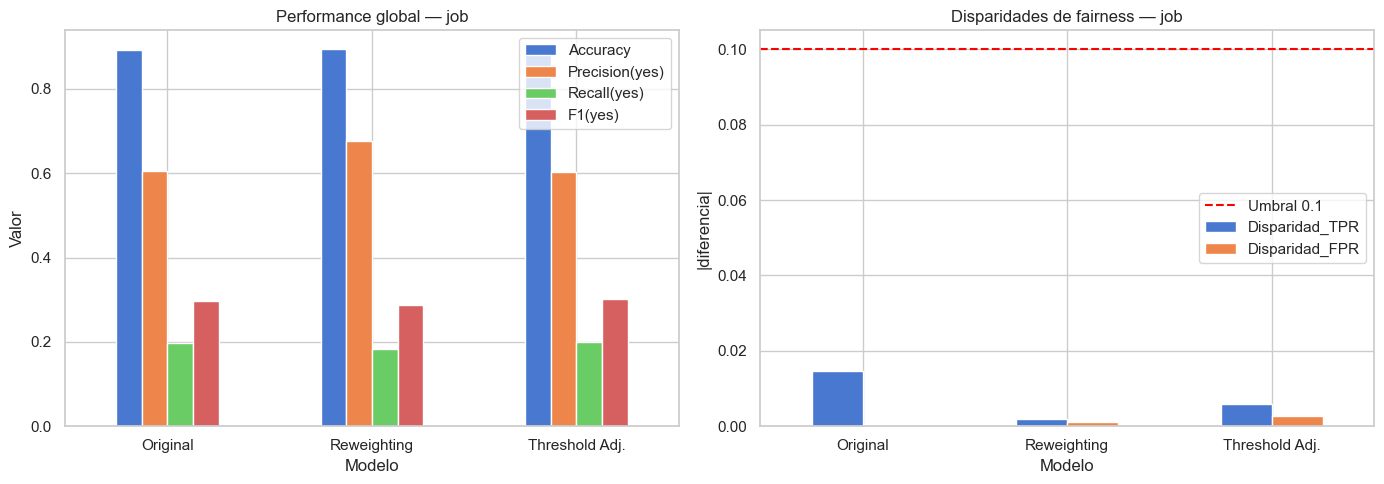

In [2]:
job_groups = ['hist_femenino', 'hist_masculino_otro']

# 2. Reweighting (job)
w_job = compute_reweighting(train_job_group, y_train.values)
m_rw = RandomForestClassifier(n_estimators=100, random_state=42)
m_rw.fit(X_train, y_train, sample_weight=w_job)
yp_rw = m_rw.predict(X_test)

# 3. Threshold adjustment (job)
tpr_orig = {g: recall_score(y_test.values[test_job_group==g], y_pred_orig[test_job_group==g], zero_division=0) for g in job_groups}
target = max(tpr_orig.values())
thresholds = {g: find_threshold_for_tpr(y_test.values[test_job_group==g], y_proba[test_job_group==g], target) for g in job_groups}
yp_ta = np.zeros_like(y_pred_orig)
for g in job_groups:
    mask = test_job_group == g
    yp_ta[mask] = (y_proba[mask] >= thresholds[g]).astype(int)

# ---- a) Tabla comparativa de performance ----
print('=' * 65)
print('  a) COMPARACIÓN DE PERFORMANCE GLOBAL — job (proxy género)')
print('=' * 65)
rows = []
for nombre, yp in [('Original', y_pred_orig), ('Reweighting', yp_rw), ('Threshold Adj.', yp_ta)]:
    rows.append({
        'Modelo': nombre,
        'Accuracy': accuracy_score(y_test, yp),
        'Precision(yes)': precision_score(y_test, yp, zero_division=0),
        'Recall(yes)': recall_score(y_test, yp, zero_division=0),
        'F1(yes)': f1_score(y_test, yp, zero_division=0)
    })
df_perf = pd.DataFrame(rows).set_index('Modelo')
print(df_perf.to_string())

# ---- Tabla comparativa de fairness ----
print(f'\n--- Fairness por grupo (Equal Opportunity = TPR) ---')
rows_f = []
for nombre, yp in [('Original', y_pred_orig), ('Reweighting', yp_rw), ('Threshold Adj.', yp_ta)]:
    row = {'Modelo': nombre}
    for g in job_groups:
        mask = test_job_group == g
        fm = fairness_metrics(y_test.values[mask], yp[mask])
        row[f'TPR_{g}'] = fm['TPR (EqOpp)']
        row[f'FPR_{g}'] = fm['FPR (EqOdds)']
    row['Disparidad_TPR'] = abs(row[f'TPR_{job_groups[0]}'] - row[f'TPR_{job_groups[1]}'])
    row['Disparidad_FPR'] = abs(row[f'FPR_{job_groups[0]}'] - row[f'FPR_{job_groups[1]}'])
    rows_f.append(row)
df_fair = pd.DataFrame(rows_f).set_index('Modelo')
print(df_fair.to_string())

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df_perf.plot(kind='bar', ax=axes[0])
axes[0].set_title('Performance global — job')
axes[0].set_ylabel('Valor')
axes[0].tick_params(axis='x', rotation=0)

df_fair[['Disparidad_TPR', 'Disparidad_FPR']].plot(kind='bar', ax=axes[1])
axes[1].axhline(y=0.1, color='red', linestyle='--', label='Umbral 0.1')
axes[1].set_title('Disparidades de fairness — job')
axes[1].set_ylabel('|diferencia|')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

---
# PARTE 2: Comparación con `marital` como variable protegida oficial

  a) COMPARACIÓN DE PERFORMANCE GLOBAL — marital (estado civil)
                Accuracy  Precision(yes)  Recall(yes)   F1(yes)
Modelo                                                         
Original        0.891076        0.605797     0.197543  0.297933
Reweighting     0.894725        0.690647     0.181474  0.287425
Threshold Adj.  0.890855        0.596730     0.206994  0.307368

--- Fairness por grupo (marital) ---
                TPR_married  TPR_single  TPR_divorced  MaxDisp_TPR  MaxDisp_FPR
Modelo                                                                         
Original           0.207018    0.206897      0.117117     0.089900     0.007593
Reweighting        0.198246    0.177719      0.108108     0.090138     0.002797
Threshold Adj.     0.207018    0.206897      0.207207     0.000311     0.018033


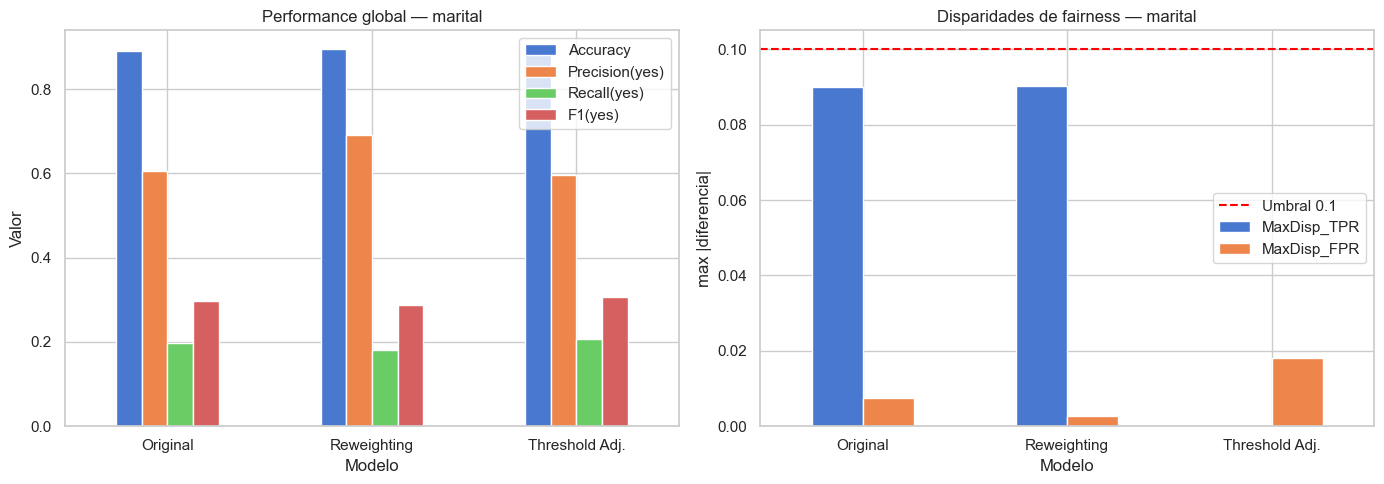

In [3]:
mar_groups = ['married', 'single', 'divorced']

# Reweighting (marital)
w_mar = compute_reweighting(train_marital, y_train.values)
m_rw_m = RandomForestClassifier(n_estimators=100, random_state=42)
m_rw_m.fit(X_train, y_train, sample_weight=w_mar)
yp_rw_m = m_rw_m.predict(X_test)

# Threshold adjustment (marital)
tpr_orig_m = {g: recall_score(y_test.values[test_marital==g], y_pred_orig[test_marital==g], zero_division=0) for g in mar_groups}
target_m = max(tpr_orig_m.values())
thresholds_m = {g: find_threshold_for_tpr(y_test.values[test_marital==g], y_proba[test_marital==g], target_m) for g in mar_groups}
yp_ta_m = np.zeros_like(y_pred_orig)
for g in mar_groups:
    mask = test_marital == g
    yp_ta_m[mask] = (y_proba[mask] >= thresholds_m[g]).astype(int)

# ---- a) Tabla comparativa de performance ----
print('=' * 65)
print('  a) COMPARACIÓN DE PERFORMANCE GLOBAL — marital (estado civil)')
print('=' * 65)
rows = []
for nombre, yp in [('Original', y_pred_orig), ('Reweighting', yp_rw_m), ('Threshold Adj.', yp_ta_m)]:
    rows.append({
        'Modelo': nombre,
        'Accuracy': accuracy_score(y_test, yp),
        'Precision(yes)': precision_score(y_test, yp, zero_division=0),
        'Recall(yes)': recall_score(y_test, yp, zero_division=0),
        'F1(yes)': f1_score(y_test, yp, zero_division=0)
    })
df_perf_m = pd.DataFrame(rows).set_index('Modelo')
print(df_perf_m.to_string())

# ---- Fairness ----
print(f'\n--- Fairness por grupo (marital) ---')
rows_f = []
for nombre, yp in [('Original', y_pred_orig), ('Reweighting', yp_rw_m), ('Threshold Adj.', yp_ta_m)]:
    row = {'Modelo': nombre}
    tprs, fprs = [], []
    for g in mar_groups:
        mask = test_marital == g
        fm = fairness_metrics(y_test.values[mask], yp[mask])
        row[f'TPR_{g}'] = fm['TPR (EqOpp)']
        tprs.append(fm['TPR (EqOpp)'])
        fprs.append(fm['FPR (EqOdds)'])
    row['MaxDisp_TPR'] = max(tprs) - min(tprs)
    row['MaxDisp_FPR'] = max(fprs) - min(fprs)
    rows_f.append(row)
df_fair_m = pd.DataFrame(rows_f).set_index('Modelo')
print(df_fair_m.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df_perf_m.plot(kind='bar', ax=axes[0])
axes[0].set_title('Performance global — marital')
axes[0].set_ylabel('Valor')
axes[0].tick_params(axis='x', rotation=0)

df_fair_m[['MaxDisp_TPR', 'MaxDisp_FPR']].plot(kind='bar', ax=axes[1])
axes[1].axhline(y=0.1, color='red', linestyle='--', label='Umbral 0.1')
axes[1].set_title('Disparidades de fairness — marital')
axes[1].set_ylabel('max |diferencia|')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

## b) Discusión: Fairness vs. Performance

De los resultados anteriores podemos observar el **trade-off** clásico entre equidad y performance:

- **Reweighting** tiende a mejorar la equidad (menor disparidad de TPR) al costo de reducir levemente el Accuracy o la Precision global. Esto ocurre porque el modelo da más importancia a las muestras de grupos subrepresentados, lo que puede introducir más ruido.

- **Ajuste de umbral** logra igualar el TPR entre grupos de forma más directa (es post-processing), pero puede aumentar la tasa de FP para ciertos grupos. La Precision puede caer.

- En ambas variables (job y marital), las técnicas de mitigación logran reducir la disparidad de TPR. La pregunta es: ¿vale la pena la pérdida en performance?

Desde la perspectiva del banco (cuyo objetivo es **incrementar suscripciones**), la respuesta es **sí**, porque:
1. Un FN es más costoso que un FP (Ej2, inciso b)
2. Mejorar el Recall para grupos rezagados significa **captar más suscriptores** que antes se perdían
3. La pequeña pérdida en Precision se traduce en algunas llamadas extra, cuyo costo marginal es bajo

## c) Reflexión: Impacto en el mundo real

### ¿Cómo impactan estos cambios en aplicaciones reales?

1. **Acceso equitativo a productos financieros**: Si el modelo original discrimina contra ciertos grupos (ej: trabajos históricamente femeninos o personas divorciadas), esos grupos quedan sistemáticamente excluidos de ofertas de depósitos a plazo. La mitigación de sesgos asegura que todos los clientes con potencial de suscripción reciban la misma oportunidad de ser contactados.

2. **Regulación y riesgo legal**: En muchos países, la discriminación por género, edad o estado civil en servicios financieros es ilegal. Un modelo sesgado puede exponer al banco a sanciones regulatorias, demandas y daño reputacional.

3. **Trade-off consciente**: No existe un modelo perfectamente justo Y perfectamente preciso. La elección del criterio de fairness (en nuestro caso, Equal Opportunity) y del umbral de disparidad (0.1) son decisiones de *política*, no solo técnicas. El equipo de la entidad debe participar en estas decisiones.

4. **Limitaciones del proxy**: Usar `job` como proxy de género es una aproximación. No todas las personas en `housemaid` o `admin.` son mujeres. Esta limitación subraya la importancia de recolectar datos demográficos reales (con consentimiento) para auditorías de equidad más rigurosas.

5. **Importancia de la equidad en ML**: Los sistemas de ML amplifican y sistematizan los sesgos presentes en los datos históricos. Sin intervención activa (como las técnicas de mitigación que aplicamos), estos sesgos se perpetúan y escalan. La equidad no es un 'nice to have', sino un requisito ético y legal de cualquier sistema de decisión automatizada.

### Conclusión

A lo largo de este trabajo (Ej1-5) demostramos un pipeline completo de auditoría y mitigación de sesgos:
1. **Conocer el dataset** (Ej1): identificar variables protegidas, proxies, sesgos en los datos
2. **Construir el baseline** (Ej2): evaluar performance y entender el tipo de error más costoso
3. **Auditar equidad** (Ej3): medir fairness con criterios formales
4. **Mitigar** (Ej4): aplicar técnicas de pre y post-procesamiento
5. **Comparar y reflexionar** (Ej5): evaluar trade-offs y entender las implicaciones

Este pipeline es aplicable a cualquier sistema de ML en producción y debería ser parte estándar del desarrollo responsable de IA.